Cellule 1 : Imports & configuration

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from scipy.spatial.distance import cdist
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

# Palette couleurs
BLEU   = "#1B3A6B"
OR     = "#D4A017"
VERT   = "#2E7D32"
ROUGE  = "#C62828"
GRIS   = "#ECEFF1"
BLEU_L = "#90CAF9"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.dpi": 150,
})

print(" Imports OK")

 Imports OK


Cellule 2 : Simulation données géographiques Nancy

In [24]:
# Bounding box Nancy métropole
LAT_MIN, LAT_MAX = 48.65, 48.72
LON_MIN, LON_MAX = 6.12, 6.22
LAT_CTR, LON_CTR = 48.692, 6.184

def rand_coords(n, lat_mu, lon_mu, lat_sd=0.02, lon_sd=0.02):
    lats = np.clip(np.random.normal(lat_mu, lat_sd, n), LAT_MIN, LAT_MAX)
    lons = np.clip(np.random.normal(lon_mu, lon_sd, n), LON_MIN, LON_MAX)
    return lats, lons

# Fast-foods
n_ff = 45
ff_lats, ff_lons = rand_coords(n_ff, LAT_CTR, LON_CTR, 0.018, 0.018)
fast_foods = pd.DataFrame({
    "lat": ff_lats, "lon": ff_lons,
    "type": "Fast-food",
    "capacite": np.random.randint(20, 80, n_ff)
})

# Supermarchés
n_sm = 22
sm_lats, sm_lons = rand_coords(n_sm, LAT_CTR, LON_CTR, 0.025, 0.025)
supermarches = pd.DataFrame({
    "lat": sm_lats, "lon": sm_lons,
    "type": "Supermarché",
    "capacite": np.random.randint(50, 200, n_sm)
})

# Espaces verts
n_ev = 18
espaces_verts = pd.DataFrame({
    "lat": np.random.uniform(LAT_MIN, LAT_MAX, n_ev),
    "lon": np.random.uniform(LON_MIN, LON_MAX, n_ev),
    "type": "Espace vert",
    "superficie_ha": np.random.uniform(0.5, 15, n_ev)
})

# Participants STANISLAS simulés (Wagner et al. 2025 : AUT=28%, SD=12%)
N_PART = 800
part_lats, part_lons = rand_coords(N_PART, LAT_CTR, LON_CTR, 0.022, 0.022)
aut_score = np.clip(np.random.normal(28, 12, N_PART), 5, 70)

participants = pd.DataFrame({
    "id": range(N_PART),
    "lat": part_lats, "lon": part_lons,
    "aut_score": aut_score,
    "age": np.random.normal(48, 14, N_PART).clip(18, 75),
    "sexe": np.random.choice([0, 1], N_PART),
    "revenu_quartile": np.random.choice([1,2,3,4], N_PART, p=[0.25]*4),
})

print(f"Participants : {N_PART}")
print(f"AUT moyen   : {aut_score.mean():.1f}% (SD={aut_score.std():.1f})")
print(f"Fast-foods  : {n_ff} | Supermarchés : {n_sm} | Espaces verts : {n_ev}")

Participants : 800
AUT moyen   : 28.7% (SD=11.6)
Fast-foods  : 45 | Supermarchés : 22 | Espaces verts : 18


Cellule 3 : Méthode E2SFCA

In [25]:
# Bounding box Nancy métropole
LAT_MIN, LAT_MAX = 48.65, 48.72
LON_MIN, LON_MAX = 6.12, 6.22
LAT_CTR, LON_CTR = 48.692, 6.184

def rand_coords(n, lat_mu, lon_mu, lat_sd=0.02, lon_sd=0.02):
    lats = np.clip(np.random.normal(lat_mu, lat_sd, n), LAT_MIN, LAT_MAX)
    lons = np.clip(np.random.normal(lon_mu, lon_sd, n), LON_MIN, LON_MAX)
    return lats, lons

# Fast-foods
n_ff = 45
ff_lats, ff_lons = rand_coords(n_ff, LAT_CTR, LON_CTR, 0.018, 0.018)
fast_foods = pd.DataFrame({
    "lat": ff_lats, "lon": ff_lons,
    "type": "Fast-food",
    "capacite": np.random.randint(20, 80, n_ff)
})

# Supermarchés
n_sm = 22
sm_lats, sm_lons = rand_coords(n_sm, LAT_CTR, LON_CTR, 0.025, 0.025)
supermarches = pd.DataFrame({
    "lat": sm_lats, "lon": sm_lons,
    "type": "Supermarché",
    "capacite": np.random.randint(50, 200, n_sm)
})

# Espaces verts
n_ev = 18
espaces_verts = pd.DataFrame({
    "lat": np.random.uniform(LAT_MIN, LAT_MAX, n_ev),
    "lon": np.random.uniform(LON_MIN, LON_MAX, n_ev),
    "type": "Espace vert",
    "superficie_ha": np.random.uniform(0.5, 15, n_ev)
})

# Participants STANISLAS simulés (Wagner et al. 2025 : AUT=28%, SD=12%)
N_PART = 800
part_lats, part_lons = rand_coords(N_PART, LAT_CTR, LON_CTR, 0.022, 0.022)
aut_score = np.clip(np.random.normal(28, 12, N_PART), 5, 70)

participants = pd.DataFrame({
    "id": range(N_PART),
    "lat": part_lats, "lon": part_lons,
    "aut_score": aut_score,
    "age": np.random.normal(48, 14, N_PART).clip(18, 75),
    "sexe": np.random.choice([0, 1], N_PART),
    "revenu_quartile": np.random.choice([1,2,3,4], N_PART, p=[0.25]*4),
})

print(f"Participants : {N_PART}")
print(f"AUT moyen   : {aut_score.mean():.1f}% (SD={aut_score.std():.1f})")
print(f"Fast-foods  : {n_ff} | Supermarchés : {n_sm} | Espaces verts : {n_ev}")

Participants : 800
AUT moyen   : 27.8% (SD=11.4)
Fast-foods  : 45 | Supermarchés : 22 | Espaces verts : 18


Cellule 4 : Machine Learning 

In [26]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Distance haversine en kilomètres."""
    R = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

def decay_gaussian(d, d0=2.0):
    """Décroissance gaussienne — Luo & Wang (2003)."""
    w = np.exp(-(d/d0)**2)
    w[d > d0 * 2] = 0
    return w

def compute_e2sfca(participants, offre_df, capacite_col, seuil_km=2.0):
    """
    E2SFCA — Enhanced Two-Step Floating Catchment Area
    Étape 1 : ratio offre/demande pour chaque point j
    Étape 2 : score accessibilité pour chaque participant i
    """
    part_coords = participants[["lat","lon"]].values
    offre_coords = offre_df[["lat","lon"]].values
    cap = offre_df[capacite_col].values

    D = np.zeros((len(part_coords), len(offre_coords)))
    for j, (lo, la) in enumerate(offre_coords):
        D[:, j] = haversine_km(part_coords[:,0], part_coords[:,1], lo, la)

    # Étape 1
    R_j = np.zeros(len(offre_coords))
    for j in range(len(offre_coords)):
        w = decay_gaussian(D[:, j], d0=seuil_km)
        demand = np.sum(w)
        R_j[j] = cap[j] / demand if demand > 0 else 0

    # Étape 2
    A_i = np.zeros(len(part_coords))
    for i in range(len(part_coords)):
        w = decay_gaussian(D[i, :], d0=seuil_km)
        A_i[i] = np.sum(w * R_j)

    return A_i

def minmax(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-9)

# Calcul des scores
acc_ff = compute_e2sfca(participants, fast_foods, "capacite", seuil_km=1.5)
acc_sm = compute_e2sfca(participants, supermarches, "capacite", seuil_km=2.0)
acc_ev = compute_e2sfca(participants, espaces_verts, "superficie_ha", seuil_km=1.0)

participants["acc_fastfood"]    = minmax(acc_ff)
participants["acc_supermarche"] = minmax(acc_sm)
participants["acc_espacevert"]  = minmax(acc_ev)

print("Scores E2SFCA calculés")
print(participants[["acc_fastfood","acc_supermarche","acc_espacevert"]].describe().round(3))

Scores E2SFCA calculés
       acc_fastfood  acc_supermarche  acc_espacevert
count       800.000          800.000         800.000
mean          0.556            0.482           0.043
std           0.246            0.178           0.076
min           0.000            0.000           0.000
25%           0.357            0.363           0.012
50%           0.511            0.500           0.023
75%           0.787            0.575           0.048
max           1.000            1.000           1.000


Cellule 5 : Code ML 

In [27]:
features = ["acc_fastfood","acc_supermarche","acc_espacevert",
            "age","sexe","revenu_quartile"]
feature_labels = [
    "Accessibilité\nfast-food (E2SFCA)",
    "Accessibilité\nsupermarché (E2SFCA)",
    "Accessibilité\nespaces verts (E2SFCA)",
    "Âge", "Sexe", "Quartile revenu"
]

X = participants[features].values
y = participants["aut_score"].values
X_scaled = StandardScaler().fit_transform(X)

rf = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
rf.fit(X_scaled, y)
rf_scores = cross_val_score(rf, X_scaled, y, cv=5, scoring="r2")

xgb = GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                 learning_rate=0.05, random_state=42)
xgb.fit(X_scaled, y)
xgb_scores = cross_val_score(xgb, X_scaled, y, cv=5, scoring="r2")

importances = rf.feature_importances_
idx_sorted  = np.argsort(importances)

print(f" Random Forest  R² CV : {rf_scores.mean():.3f} ± {rf_scores.std():.3f}")
print(f"XGBoost        R² CV : {xgb_scores.mean():.3f} ± {xgb_scores.std():.3f}")

 Random Forest  R² CV : -0.043 ± 0.014
XGBoost        R² CV : -0.142 ± 0.040


Cellule 6: Visualisation

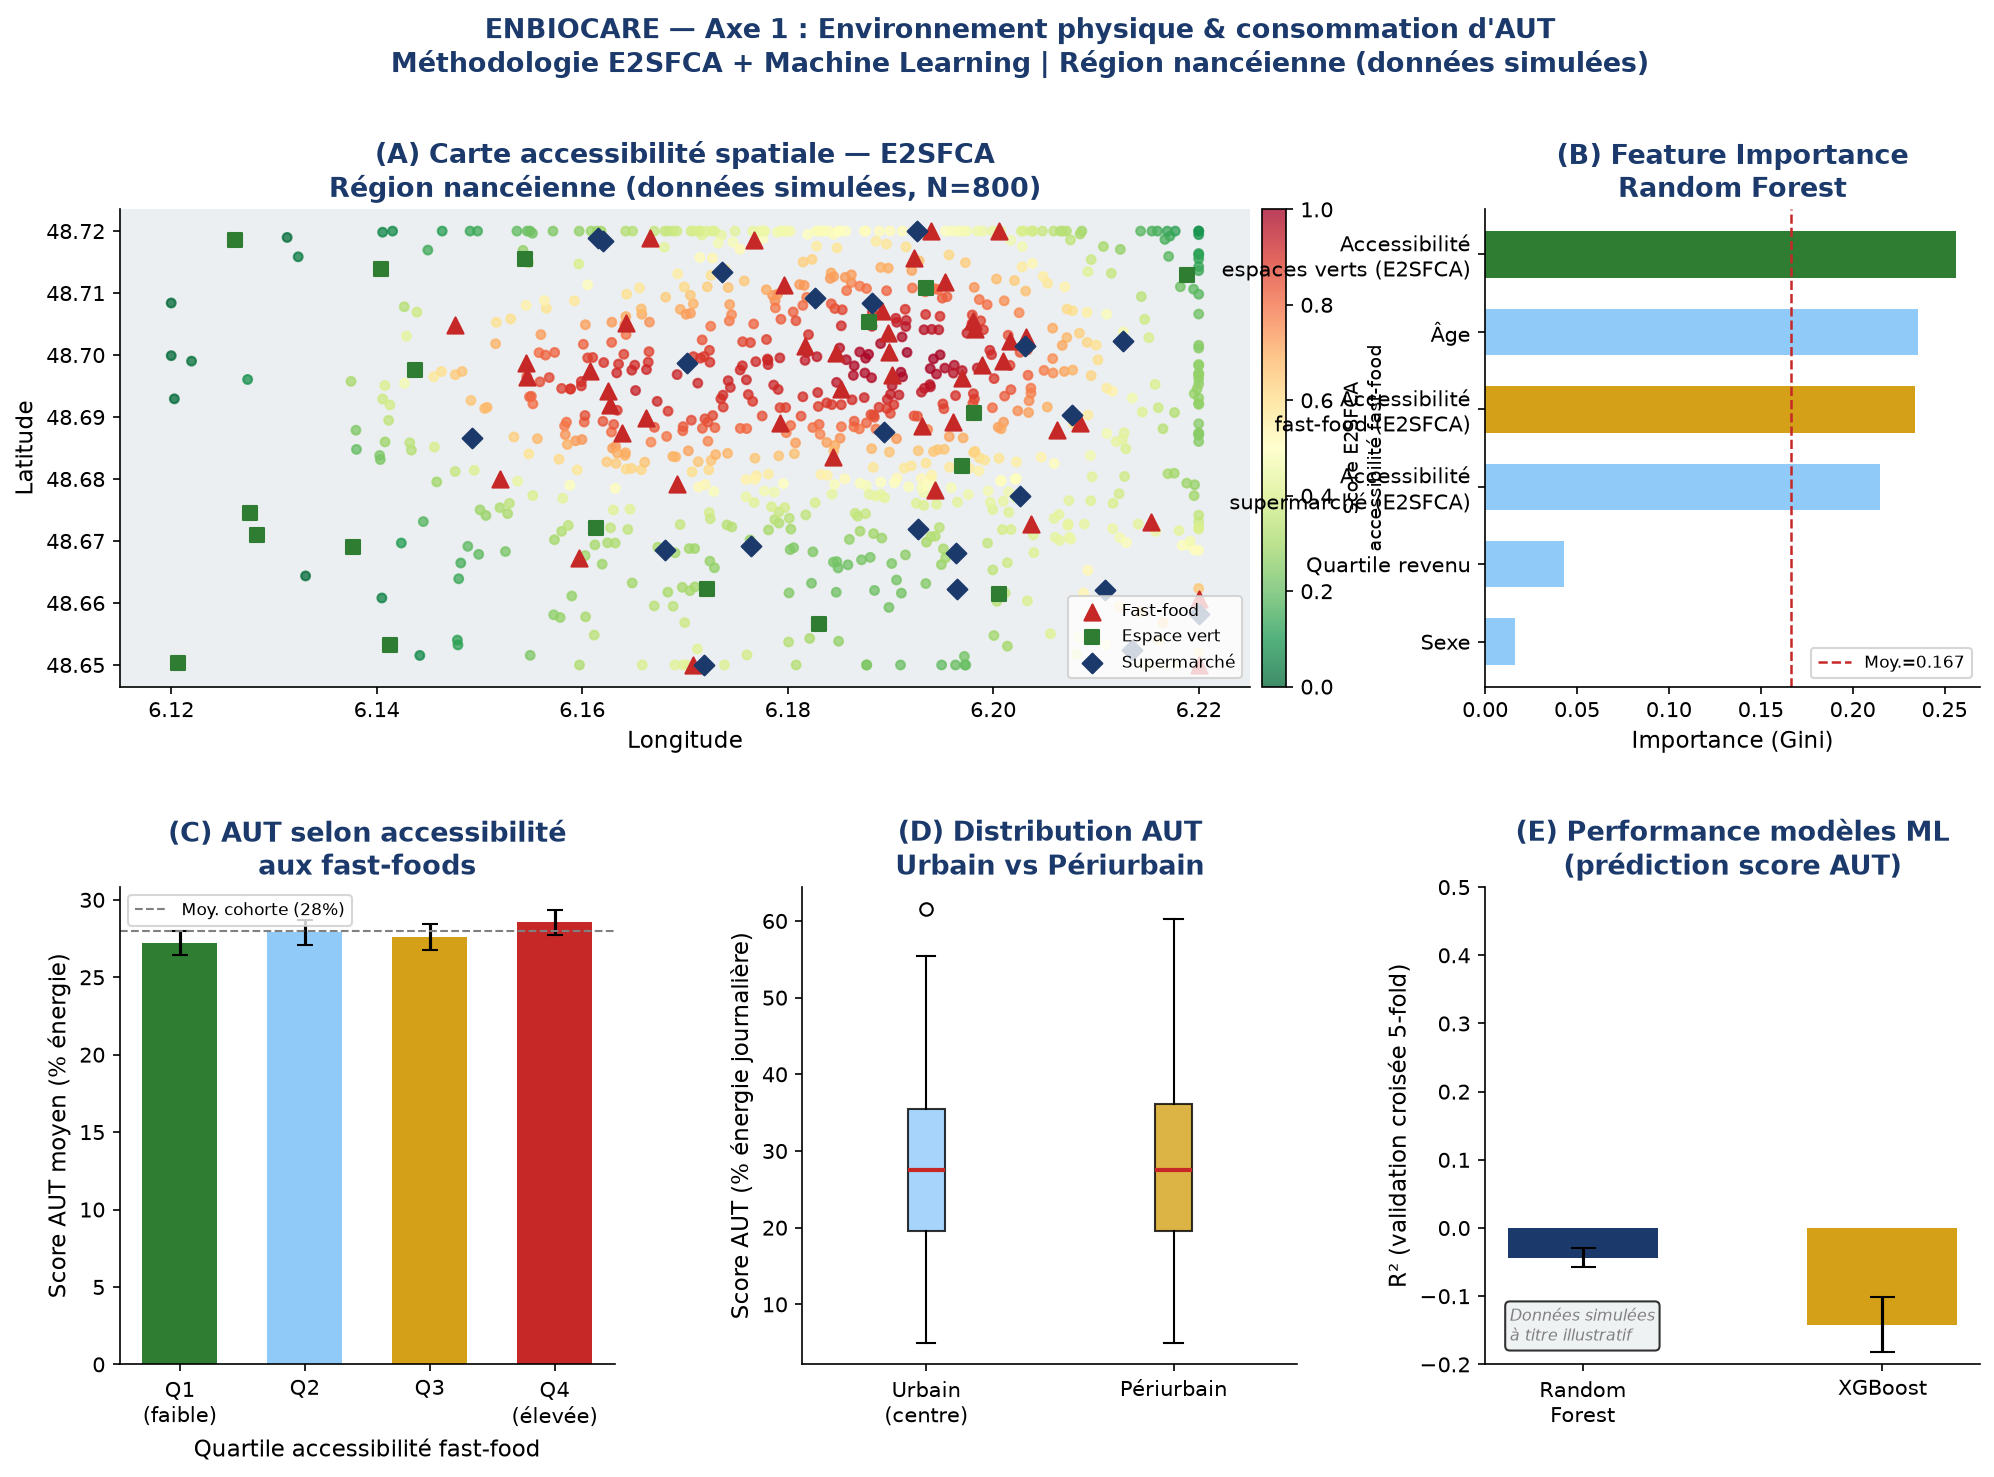

 Figure sauvegardée dans figures/axe1_figure.png


In [29]:

importances = rf.feature_importances_
idx_sorted  = np.argsort(importances)

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor("white")
gs = GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

# (A) Carte choroplèthe
ax1 = fig.add_subplot(gs[0, :2])
sc = ax1.scatter(participants["lon"], participants["lat"],
                 c=participants["acc_fastfood"],
                 cmap="RdYlGn_r", s=18, alpha=0.75, vmin=0, vmax=1, zorder=2)
ax1.scatter(fast_foods["lon"], fast_foods["lat"],
            marker="^", s=60, color=ROUGE, label="Fast-food", zorder=4)
ax1.scatter(espaces_verts["lon"], espaces_verts["lat"],
            marker="s", s=45, color=VERT, label="Espace vert", zorder=4)
ax1.scatter(supermarches["lon"], supermarches["lat"],
            marker="D", s=45, color=BLEU, label="Supermarché", zorder=4)
cb = plt.colorbar(sc, ax=ax1, fraction=0.03, pad=0.01)
cb.set_label("Score E2SFCA\naccessibilité fast-food", fontsize=9)
ax1.set_xlabel("Longitude"); ax1.set_ylabel("Latitude")
ax1.set_title("(A) Carte accessibilité spatiale — E2SFCA\nRégion nancéienne (données simulées, N=800)",
              fontweight="bold", color=BLEU)
ax1.legend(loc="lower right", fontsize=8)
ax1.set_facecolor(GRIS)

# (B) Feature Importance
ax2 = fig.add_subplot(gs[0, 2])
colors_fi = [OR if "fast" in feature_labels[i].lower()
             else VERT if "vert" in feature_labels[i].lower()
             else BLEU_L for i in idx_sorted]
bars = ax2.barh([feature_labels[i] for i in idx_sorted],
                importances[idx_sorted], color=colors_fi, height=0.6)
ax2.set_xlabel("Importance (Gini)")
ax2.set_title("(B) Feature Importance\nRandom Forest", fontweight="bold", color=BLEU)
ax2.axvline(importances.mean(), color=ROUGE, ls="--", lw=1.2,
            label=f"Moy.={importances.mean():.3f}")
ax2.legend(fontsize=8)

# (C) AUT par quartile accessibilité
ax3 = fig.add_subplot(gs[1, 0])
q_labels = pd.qcut(participants["acc_fastfood"], 4,
                   labels=["Q1\n(faible)","Q2","Q3","Q4\n(élevée)"])
qmeans = participants.groupby(q_labels, observed=True)["aut_score"].mean()
qsems  = participants.groupby(q_labels, observed=True)["aut_score"].sem()
ax3.bar(qmeans.index, qmeans.values, yerr=qsems.values,
        color=[VERT,BLEU_L,OR,ROUGE], capsize=4, width=0.6)
ax3.axhline(28, color="gray", ls="--", lw=1, label="Moy. cohorte (28%)")
ax3.set_xlabel("Quartile accessibilité fast-food")
ax3.set_ylabel("Score AUT moyen (% énergie)")
ax3.set_title("(C) AUT selon accessibilité\naux fast-foods",
              fontweight="bold", color=BLEU)
ax3.legend(fontsize=8)

# (D) Urbain vs Périurbain
ax4 = fig.add_subplot(gs[1, 1])
dist_centre = haversine_km(participants["lat"].values, participants["lon"].values,
                            LAT_CTR, LON_CTR)
participants["zone"] = np.where(dist_centre < 2.5, "Urbain\n(centre)", "Périurbain")
urbain     = participants[participants["zone"]=="Urbain\n(centre)"]["aut_score"]
periurbain = participants[participants["zone"]=="Périurbain"]["aut_score"]
bp = ax4.boxplot([urbain, periurbain], tick_labels=["Urbain\n(centre)","Périurbain"],
                 patch_artist=True, medianprops=dict(color=ROUGE, lw=2))
bp["boxes"][0].set_facecolor(BLEU_L); bp["boxes"][0].set_alpha(0.8)
bp["boxes"][1].set_facecolor(OR);     bp["boxes"][1].set_alpha(0.8)
ax4.set_ylabel("Score AUT (% énergie journalière)")
ax4.set_title("(D) Distribution AUT\nUrbain vs Périurbain",
              fontweight="bold", color=BLEU)

# (E) Performance ML
ax5 = fig.add_subplot(gs[1, 2])
bars5 = ax5.bar(["Random\nForest","XGBoost"],
                [rf_scores.mean(), xgb_scores.mean()],
                yerr=[rf_scores.std(), xgb_scores.std()],
                color=[BLEU, OR], capsize=6, width=0.5)
ax5.set_ylabel("R² (validation croisée 5-fold)")
ax5.set_title("(E) Performance modèles ML\n(prédiction score AUT)",
              fontweight="bold", color=BLEU)
ax5.set_ylim(-0.2, 0.5)
ax5.text(0.05, 0.05, "Données simulées\nà titre illustratif",
         transform=ax5.transAxes, fontsize=7.5, color="gray", style="italic",
         bbox=dict(boxstyle="round", facecolor=GRIS, alpha=0.8))

fig.suptitle(
    "ENBIOCARE — Axe 1 : Environnement physique & consommation d'AUT\n"
    "Méthodologie E2SFCA + Machine Learning | Région nancéienne (données simulées)",
    fontsize=13, fontweight="bold", color=BLEU, y=1.01
)

plt.tight_layout()
plt.savefig("../figures/axe1_figure.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print(" Figure sauvegardée dans figures/axe1_figure.png")